**Laser Dynamics as a Nonlinear Dynamical System**

This Jupyter notebook includes the supporting codes for the Term paper: " Laser Dynamics as a Nonlinear Dynamical System"

Submitted by : AMARNATH (MS22070)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp



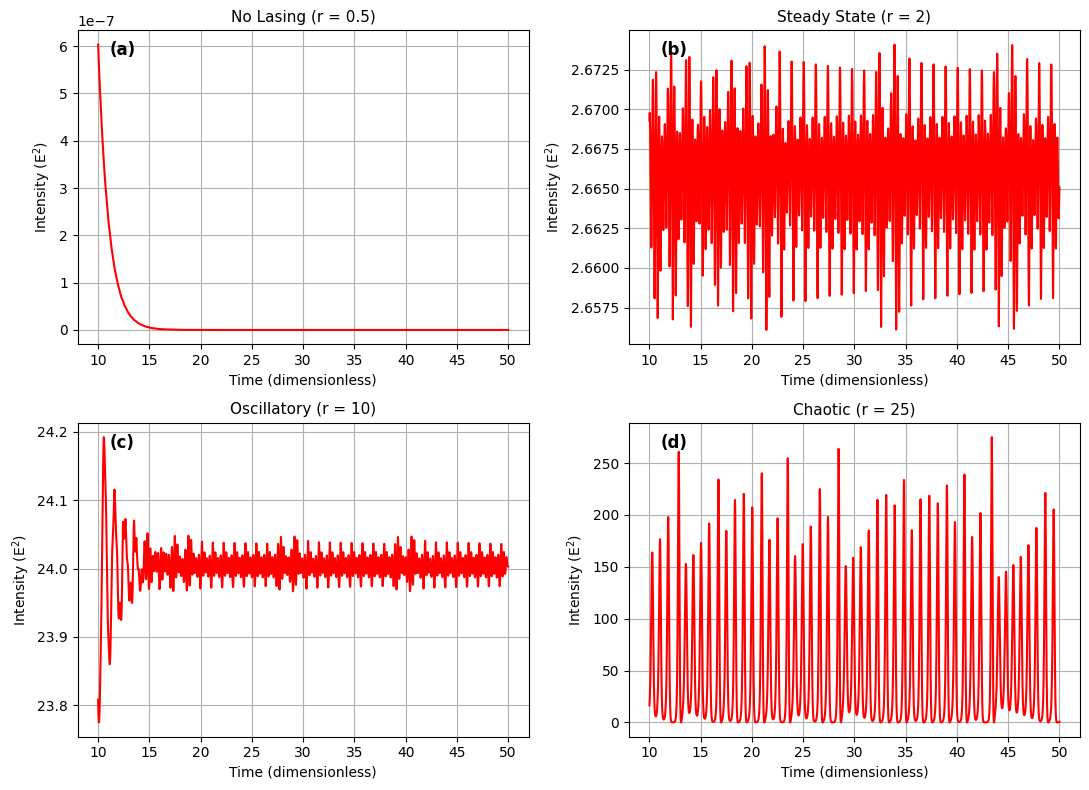

In [ ]:
# Lorenz–Haken system
def laser_system(t, y, sigma, b, r):
    E, P, D = y
    
    dE_dt = sigma * (P - E)
    dP_dt = E * D - P
    dD_dt = -E * P - b * (D - r)
    
    return [dE_dt, dP_dt, dD_dt]

# parameters
sigma = 10
b = 8/3

# time
t_span = (0, 50)
t_eval = np.linspace(0, 50, 5000)

# initial condition
y0 = [0.1, 0.1, 0.1]

# r values for different regimes
cases = [
    (0.5, "No Lasing"),
    (2, "Steady State"),
    (10, "Oscillatory"),
    (25, "Chaotic")
]

#plotting
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for i, (r, label) in enumerate(cases):
    
    sol = solve_ivp(laser_system, t_span, y0,
                    args=(sigma, b, r),
                    t_eval=t_eval)
    
    E = sol.y[0]
    I = E**2
    
    # remove transient
    t = sol.t[1000:]
    I = I[1000:]
    
    ax = axes[i//2, i%2]
    
    ax.plot(t, I,color='red')
    
    ax.set_title(f"{label} (r = {r})", fontsize=11)
    
    
    ax.set_xlabel("Time (dimensionless)")
    ax.set_ylabel("Intensity (E$^2$)")
    
    ax.text(0.07, 0.92, f"({chr(97+i)})",
            transform=ax.transAxes,
            fontsize=12,
            fontweight='bold')
    
    ax.grid()

plt.tight_layout()

plt.savefig("multi_timeseries.png", dpi=300)
plt.show()

In [40]:
print(r)

25


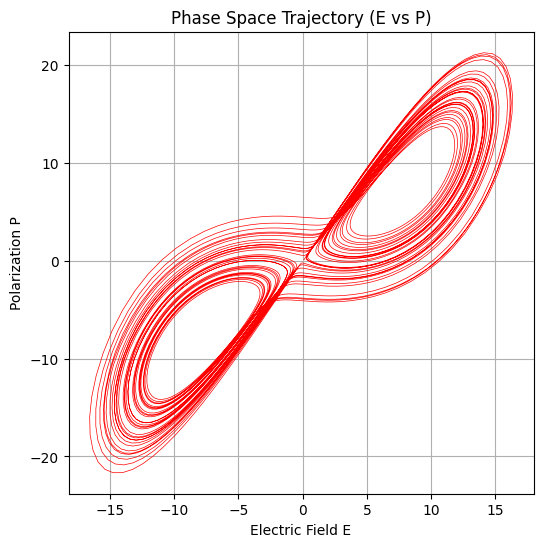

In [38]:
# 2D Phase Space: E vs P

plt.figure(figsize=(6,6))
plt.plot(E, sol.y[1], linewidth=0.5,color='red')  # P is sol.y[1]

plt.xlabel("Electric Field E")
plt.ylabel("Polarization P")
plt.title("Phase Space Trajectory (E vs P)")
plt.grid()

plt.savefig("phase_space.png", dpi=300)
plt.show()

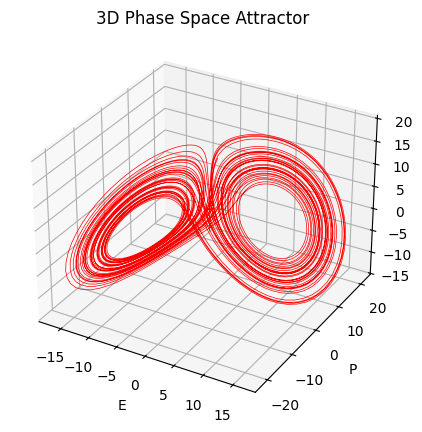

In [41]:
from mpl_toolkits.mplot3d import Axes3D

P = sol.y[1]
D = sol.y[2]

fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')

ax.plot(E, P, D, linewidth=0.5,color='red')

ax.set_xlabel("E")
ax.set_ylabel("P")
ax.set_zlabel("D")
ax.set_title("3D Phase Space Attractor")

plt.savefig("phase_space_3d.png", dpi=300)
plt.show()

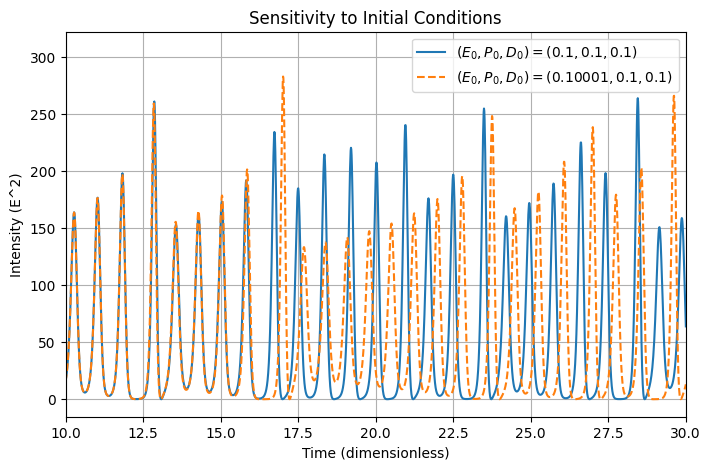

In [ ]:
# Sensitivity to Initial Conditions
# initial conditions E0, P0, D0 (very close)
y0_1 = [0.1, 0.1, 0.1]
y0_2 = [0.10001, 0.1, 0.1]

# solve both
sol1 = solve_ivp(laser_system, t_span, y0_1,
                 args=(sigma, b, r),
                 t_eval=t_eval)

sol2 = solve_ivp(laser_system, t_span, y0_2,
                 args=(sigma, b, r),
                 t_eval=t_eval)

E1 = sol1.y[0]
E2 = sol2.y[0]

# plot intensity
plt.figure(figsize=(8,5))

plt.plot(sol1.t, E1**2,
         label=r"$(E_0, P_0, D_0) = (0.1, 0.1, 0.1)$")

plt.plot(sol2.t, E2**2, '--',
         label=r"$(E_0, P_0, D_0) = (0.10001, 0.1, 0.1)$")

plt.xlabel("Time (dimensionless)")
plt.ylabel("Intensity (E^2)")
plt.title("Sensitivity to Initial Conditions")

plt.legend()
plt.grid()
plt.xlim(10, 30)

plt.savefig("sensitivity.png", dpi=300)
plt.show()

In [43]:
print(r)

25


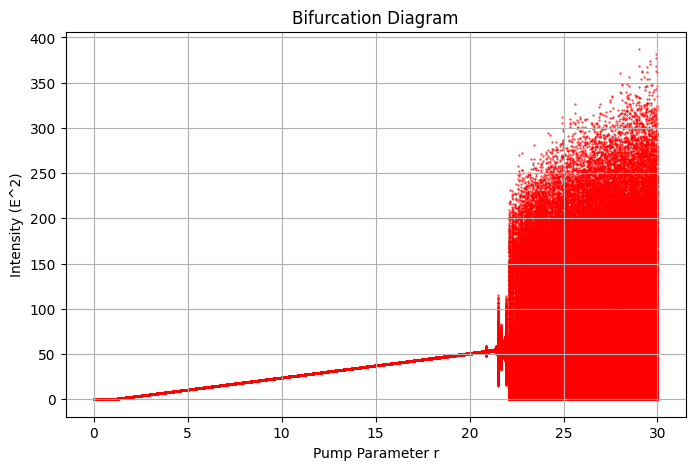

In [ ]:
# Bifurcation Diagramm study
# parameter range
r_values = np.linspace(0, 30, 900)

# storage
r_plot = []
E_plot = []

# Loop over r
for r in r_values:
    
    y0 = [0.1, 0.1, 0.1]
    
    sol = solve_ivp(laser_system, (0, 100), y0,
                    args=(sigma, b, r),
                    t_eval=np.linspace(0, 100, 4000))
    
    E = sol.y[0]
    
    # remove transient
    E_ss = E[3000:]
    
    # store points
    for val in E_ss:
        r_plot.append(r)
        E_plot.append(val**2)

# Plot
plt.figure(figsize=(8,5))
plt.scatter(r_plot, E_plot, s=0.2,color='red')

plt.xlabel("Pump Parameter r")
plt.ylabel("Intensity (E^2)")
plt.title("Bifurcation Diagram")
plt.grid()

plt.savefig("bifurcation.png", dpi=300)
plt.show()

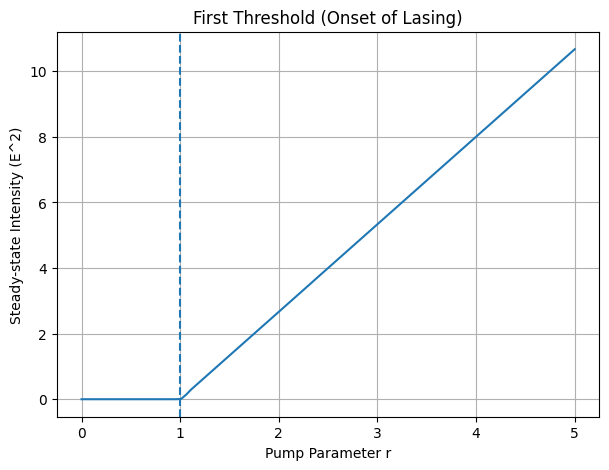

In [51]:
r_values = np.linspace(0, 5, 100)
E_ss_vals = []

for r in r_values:
    sol = solve_ivp(laser_system, (0, 50), y0,
                    args=(sigma, b, r),
                    t_eval=np.linspace(0, 50, 2000))
    
    E = sol.y[0]
    
    # steady-state value (last point)
    E_ss = np.mean(E[-200:])
    
    E_ss_vals.append(E_ss**2)

# plot
plt.figure(figsize=(7,5))
plt.plot(r_values, E_ss_vals)

plt.axvline(1, linestyle='--')  # threshold marker

plt.xlabel("Pump Parameter r")
plt.ylabel("Steady-state Intensity (E^2)")
plt.title("First Threshold (Onset of Lasing)")
plt.grid()

plt.savefig("first_threshold.png", dpi=300)
plt.show()

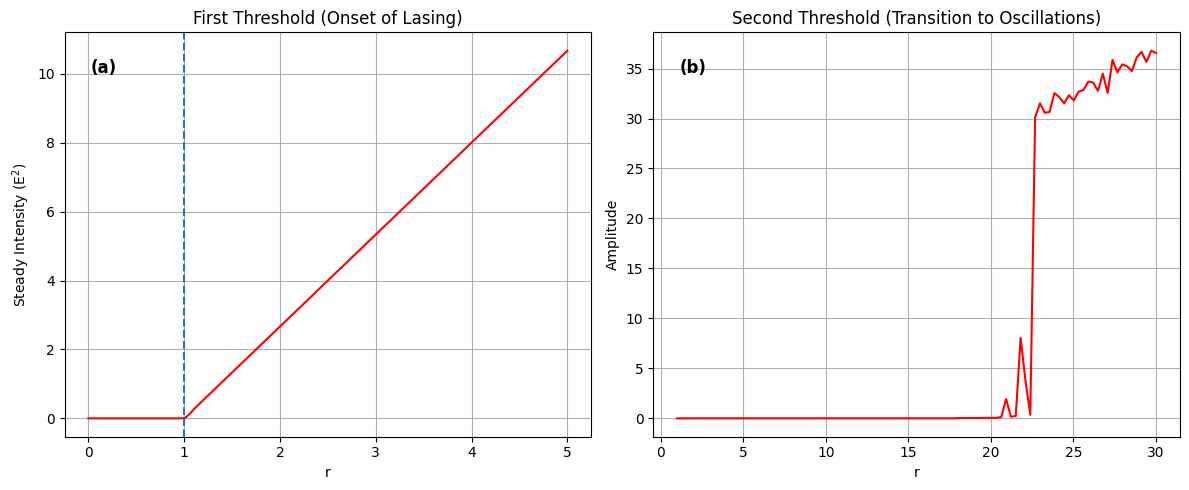

In [55]:
# First and second threshold data
sigma = 10
b = 8/3
y0 = [0.1, 0.1, 0.1]


# first threshold
r1 = np.linspace(0, 5, 100)
E_ss_vals = []

for r in r1:
    sol = solve_ivp(laser_system, (0, 50), y0,
                    args=(sigma, b, r),
                    t_eval=np.linspace(0, 50, 2000))
    
    E = sol.y[0]
    E_ss = np.mean(E[-200:])
    E_ss_vals.append(E_ss**2)

# second threshold
r2 = np.linspace(1, 30, 100)
amplitude = []

for r in r2:
    sol = solve_ivp(laser_system, (0, 100), y0,
                    args=(sigma, b, r),
                    t_eval=np.linspace(0, 100, 4000))
    
    E = sol.y[0]
    E_ss = E[3000:]
    
    amp = np.max(E_ss) - np.min(E_ss)
    amplitude.append(amp)

#plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


axes[0].plot(r1, E_ss_vals,color='red')
axes[0].axvline(1, linestyle='--')
axes[0].set_xlabel("r")
axes[0].set_ylabel("Steady Intensity (E$^2$)")
axes[0].set_title("First Threshold (Onset of Lasing)")
axes[0].text(0.05, 0.9, "(a)", transform=axes[0].transAxes,
             fontsize=12, fontweight='bold')
axes[0].grid()

axes[1].plot(r2, amplitude,color='red')
axes[1].set_xlabel("r")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Second Threshold (Transition to Oscillations)")
axes[1].text(0.05, 0.9, "(b)", transform=axes[1].transAxes,
             fontsize=12, fontweight='bold')
axes[1].grid()

plt.tight_layout()

plt.savefig("thresholds.png", dpi=300)
plt.show()

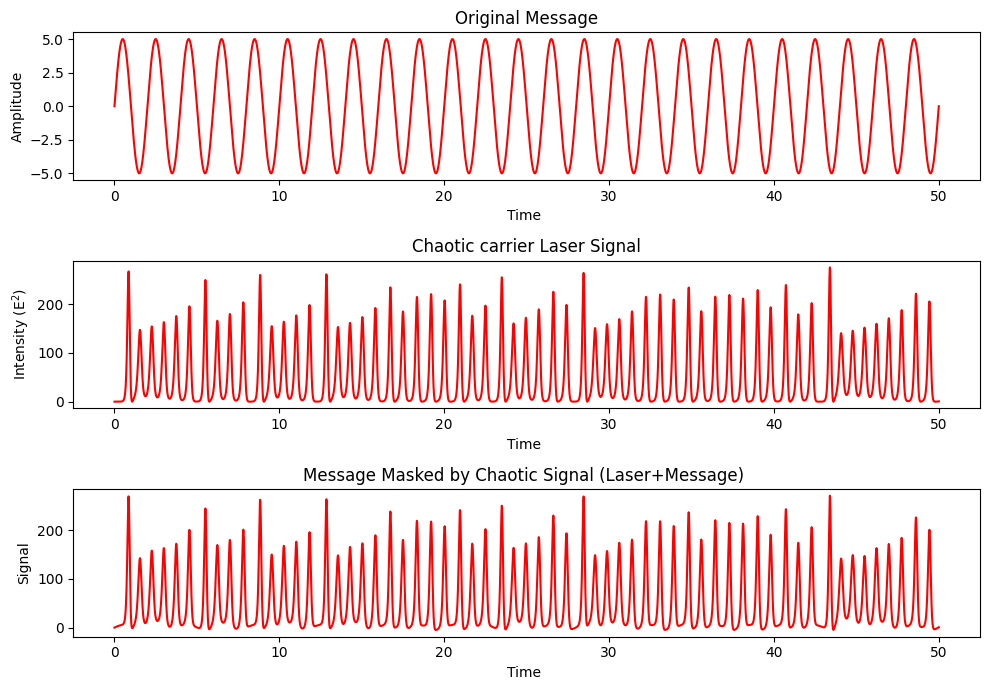

In [67]:
# Signal Masking with Chaotic Laser Output
r = 25  # chaotic regime

sol = solve_ivp(laser_system, (0, 50), y0,
                args=(sigma, b, r),
                t_eval=np.linspace(0, 50, 5000))

t = sol.t
E = sol.y[0]
chaos = E**2


# Message 
message = 5.0 * np.sin(2 * np.pi * 0.5 * t)

#masking
masked = chaos + message

# plot
plt.figure(figsize=(10,7))


plt.subplot(3,1,1)
plt.plot(t, message,color='red')
plt.title("Original Message")
plt.xlabel("Time ")
plt.ylabel("Amplitude")

plt.subplot(3,1,2)
plt.plot(t, chaos,color='red')
plt.title("Chaotic carrier Laser Signal")
plt.xlabel("Time ")
plt.ylabel("Intensity (E$^2$)")

plt.subplot(3,1,3)
plt.plot(t, masked,color='red')
plt.title("Message Masked by Chaotic Signal (Laser+Message) ")
plt.xlabel("Time ")
plt.ylabel("Signal")




plt.tight_layout()
plt.savefig("chaos_masking.png", dpi=300)
plt.show()